In [1]:
import os
    
import sys
import numpy as np

import torch
import zuko
    
from geobed.utils.sample_distribution import SampleDistribution
from geobed import BED_base_explicit, BED_base_nuisance

if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True
    os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'

    os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'

    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)

from helpers.geographic_setup import (
    design_space_full,
)    

from helpers.likelihood import DataLikelihood
from helpers.forward import TTLookup

from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle.mplstyle')


PLOT_SETUP = False
n_workers = 1  # or lower, depending on the task

In [2]:
design_space = design_space_full

model_prior_samples = torch.load('data/priors/prior_samples_full_disp.pt')
model_prior_sample_dist = SampleDistribution(model_prior_samples)

forward_function = TTLookup(
    model_prior_samples, design_space_full,
    torch.load('data/data_lookup/gradient_full_disp.pt'),)

data_likelihood = DataLikelihood(
                forward_function=forward_function,
                dependence_distance=100.0,
                vel_sigma=0.05,
                tt_obs_std=0.01, 
            )

BED_class = BED_base_explicit(
    data_likelihood_func=data_likelihood,
    m_prior_dist=model_prior_sample_dist,
)

In [3]:
N_scenarios = [100, 200, 500, 1000, 2000, 5000, 10000]

N_designs = 100
N_rec = 5

torch.manual_seed(0)
designs = torch.stack([
    design_space[
        torch.randperm(len(design_space))[:N_rec]] 
    for _ in range(N_designs)])

In [4]:
EIG_dict = {}
info_dict = {}

for N in N_scenarios:
    
    print(f'Calculating EIG for N = {N}')
    
    eig, info = BED_class.calculate_EIG(
    designs,
    eig_method='NMC',
    eig_method_kwargs=dict(
        N = N, reuse_M = True, memory_efficient = True,),
    num_workers=n_workers,
    random_seed=0,
    progress_bar=True,
    parallel_library='mpire',
    filename=f'convergence_analysis/data/EIG_NMC_no_att_{N}.pt',
    )
    
    EIG_dict[N] = eig
    info_dict[N] = info

Calculating EIG for N = 100
Calculating EIG for N = 200
Calculating EIG for N = 500
Calculating EIG for N = 1000
Calculating EIG for N = 2000
Calculating EIG for N = 5000
Calculating EIG for N = 10000


In [5]:
walltime_dict = {}
for N in N_scenarios:
    # Extract all wall times for this N
    wall_times = [info['wall_time'] for info in info_dict[N]]
    # Calculate mean wall time
    walltime_dict[N] = np.mean(wall_times)

print("Mean wall times for each N:")
for N in sorted(walltime_dict.keys()):
    print(f"N = {N}: {walltime_dict[N]:.2f} seconds")

Mean wall times for each N:
N = 100: 0.04 seconds
N = 200: 0.06 seconds
N = 500: 0.17 seconds
N = 1000: 0.45 seconds
N = 2000: 1.49 seconds
N = 5000: 7.62 seconds
N = 10000: 28.85 seconds


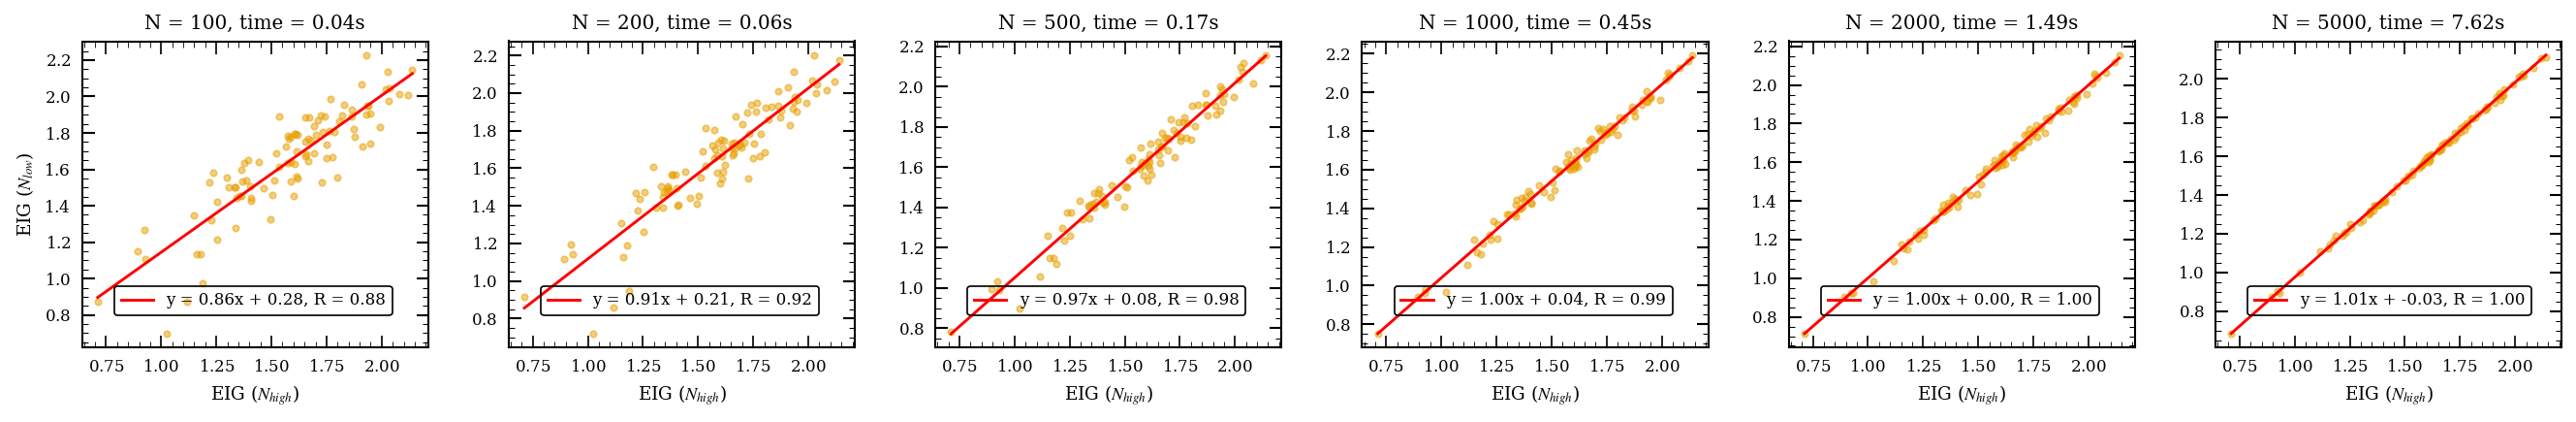

In [19]:
N_plot = [100, 200, 500, 1000, 2000, 5000]

fig, axs = plt.subplots(
    1, len(N_plot),
    figsize=(3 * len(N_plot), 3))

axs = axs.ravel()

for i, N_low in enumerate(N_plot):
    # Get EIGs for N_low and N_high
    N_high = N_scenarios[-1]
    
    # Get EIG data for both N values from EIG_dict
    eig_low = EIG_dict[N_low]
    eig_high = EIG_dict[N_high]
    
    # Fit line
    slope, intercept = np.polyfit(eig_high, eig_low, 1)
    line_x = np.array([eig_high.min(), eig_high.max()])
    line_y = slope * line_x + intercept
    
    # Calculate correlation coefficient (R value)
    R_value = np.corrcoef(eig_high, eig_low)[0, 1]
    
    # Plot
    axs[i].scatter(eig_high, eig_low, alpha=0.5, s=10)
    axs[i].plot(line_x, line_y, 'r-', label=f'y = {slope:.2f}x + {intercept:.2f}, R = {R_value:.2f}')
    axs[i].set_xlabel(f'EIG ($N_{{high}}$)')
    if i == 0:
        axs[i].set_ylabel(f'EIG ($N_{{low}}$)')
    axs[i].set_title(f'N = {N_low}, time = {walltime_dict[N_low]:.2f}s')
    
    axs[i].legend()
    
plt.tight_layout()
plt.show()

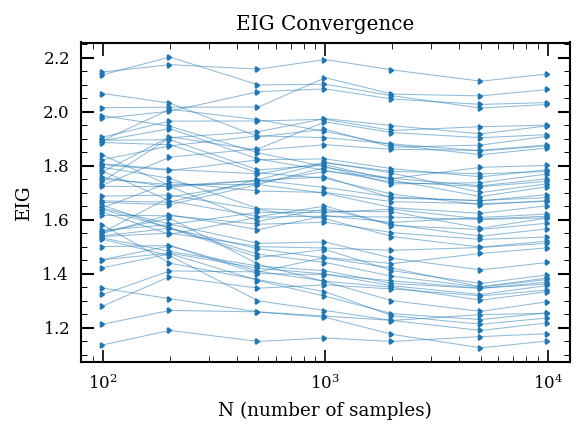

In [7]:
N_designs_plot = 50

# Create a figure with a single axis
fig, ax = plt.subplots(figsize=(4, 3))

# Plot individual design trajectories with low opacity
for design_idx in range(len(designs[:N_designs_plot])):
    eig_values = [EIG_dict[(N)][design_idx].item() for N in N_scenarios]
    ax.plot(N_scenarios, eig_values, color='tab:blue', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.scatter(N_scenarios, eig_values, color='tab:blue', s=5, marker=5)

# Set log scale for x-axis
ax.set_xscale('log')

# Add labels and title
ax.set_xlabel('N (number of samples)')
ax.set_ylabel('EIG')
ax.set_title('EIG Convergence')


plt.tight_layout()
plt.show()

In [8]:
EIG_dict_DN = {}
info_dict_DN = {}

for N in N_scenarios:
    
    print(f'Calculating EIG for N = {N}')
    
    eig, info = BED_class.calculate_EIG(
    designs,
    eig_method='DN',
    eig_method_kwargs=dict(
        N = N),
    num_workers=n_workers,
    random_seed=0,
    progress_bar=True,
    parallel_library='mpire',
    filename=f'convergence_analysis/data/EIG_DN_no_att_{N}.pt',
    )
    
    EIG_dict_DN[N] = eig
    info_dict_DN[N] = info

Calculating EIG for N = 100
Calculating EIG for N = 200
Calculating EIG for N = 500
Calculating EIG for N = 1000
Calculating EIG for N = 2000
Calculating EIG for N = 5000
Calculating EIG for N = 10000


In [9]:
walltime_dict_DN = {}
for N in N_scenarios:
    # Extract all wall times for this N
    wall_times = [info['wall_time'] for info in info_dict_DN[N]]
    # Calculate mean wall time
    walltime_dict_DN[N] = np.mean(wall_times)

print("Mean wall times for each N:")
for N in sorted(walltime_dict_DN.keys()):
    print(f"N = {N}: {walltime_dict_DN[N]:.2f} seconds")

Mean wall times for each N:
N = 100: 0.01 seconds
N = 200: 0.01 seconds
N = 500: 0.02 seconds
N = 1000: 0.04 seconds
N = 2000: 0.08 seconds
N = 5000: 0.20 seconds
N = 10000: 0.41 seconds


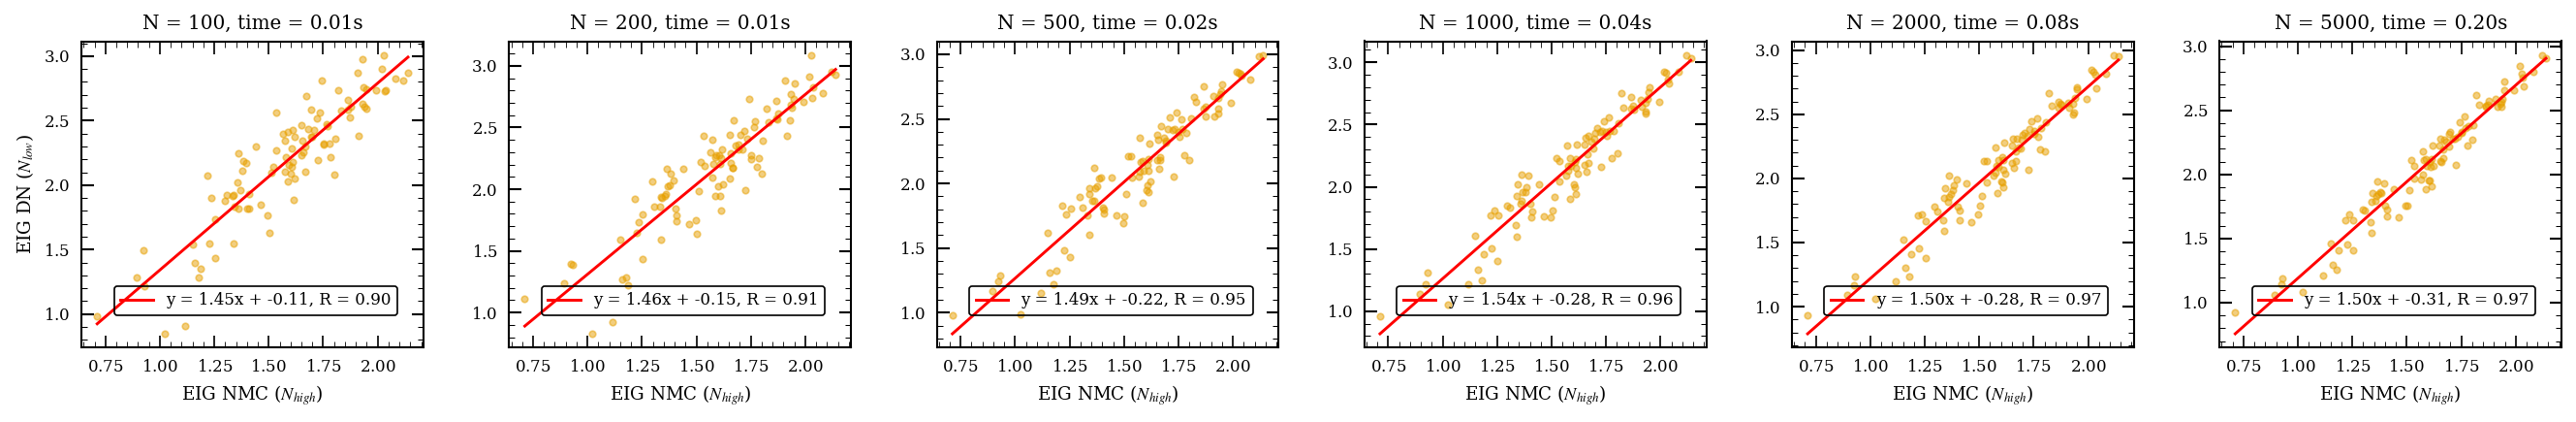

In [20]:
# For each N except the highest, plot DN EIGs against NMC high
N_plot = [100, 200, 500, 1000, 2000, 5000]

fig, axs = plt.subplots(
    1, len(N_plot),
    figsize=(3 * (len(N_plot)), 3))

axs = axs.ravel()

for i, N_low in enumerate(N_plot):
    # Get EIGs for N_low from DN and N_high from NMC
    N_high = N_scenarios[-1]
    
    # Get EIG data for both methods
    eig_dn = EIG_dict_DN[N_low]
    eig_nmc = EIG_dict[N_high]
    
    # Fit line
    slope, intercept = np.polyfit(eig_nmc, eig_dn, 1)  
    line_x = np.array([eig_nmc.min(), eig_nmc.max()])
    line_y = slope * line_x + intercept
    
    # Calculate correlation coefficient (R value)
    R_value = np.corrcoef(eig_nmc, eig_dn)[0, 1]
    
    # Plot
    axs[i].scatter(eig_nmc, eig_dn, alpha=0.5, s=10)  
    axs[i].plot(line_x, line_y, 'r-', label=f'y = {slope:.2f}x + {intercept:.2f}, R = {R_value:.2f}')
    axs[i].set_xlabel(f'EIG NMC ($N_{{high}}$)')
    if i == 0:
        axs[i].set_ylabel(f'EIG DN ($N_{{low}}$)')
    axs[i].set_title(f'N = {N_low}, time = {walltime_dict_DN[N_low]:.2f}s')
    
    axs[i].legend()
    
plt.tight_layout()
plt.show()

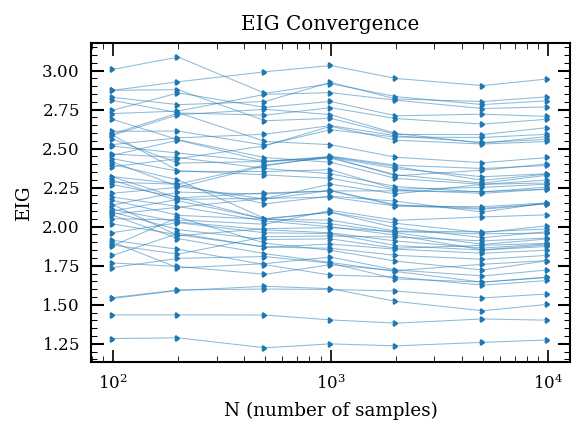

In [11]:
N_designs_plot = 50

# Create a figure with a single axis
fig, ax = plt.subplots(figsize=(4, 3))

# Plot individual design trajectories with low opacity
for design_idx in range(len(designs[:N_designs_plot])):
    eig_values = [EIG_dict_DN[(N)][design_idx].item() for N in N_scenarios]
    ax.plot(N_scenarios, eig_values, color='tab:blue', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.scatter(N_scenarios, eig_values, color='tab:blue', s=5, marker=5)

# Set log scale for x-axis
ax.set_xscale('log')

# Add labels and title
ax.set_xlabel('N (number of samples)')
ax.set_ylabel('EIG')
ax.set_title('EIG Convergence')


plt.tight_layout()
plt.show()

# No Data Correlation

In [12]:
data_likelihood_no_corr = DataLikelihood(
                forward_function=forward_function,
                dependence_distance=0.0,
                vel_sigma=0.05,
                tt_obs_std=0.01, 
            )

BED_class_no_corr = BED_base_explicit(
    data_likelihood_func=data_likelihood_no_corr,
    m_prior_dist=model_prior_sample_dist,
)

In [13]:
EIG_dict_no_corr = {}
info_dict_no_corr = {}

for N in N_scenarios:
    
    print(f'Calculating EIG for N = {N}')
    
    eig, info = BED_class_no_corr.calculate_EIG(
        designs,
        eig_method='NMC',
        eig_method_kwargs=dict(
            N = N, reuse_M = True, memory_efficient = True,),
        num_workers=n_workers,
        random_seed=0,
        progress_bar=True,
        parallel_library='mpire',
        filename=f'convergence_analysis/data/EIG_NMC_no_att_no_corr_{N}.pt',
        )
        
    EIG_dict_no_corr[N] = eig
    info_dict_no_corr[N] = info

Calculating EIG for N = 100
Calculating EIG for N = 200
Calculating EIG for N = 500
Calculating EIG for N = 1000
Calculating EIG for N = 2000
Calculating EIG for N = 5000
Calculating EIG for N = 10000


In [14]:
walltime_dict_no_corr = {}
for N in N_scenarios:
    # Extract all wall times for this N
    wall_times = [info['wall_time'] for info in info_dict_no_corr[N]]
    # Calculate mean wall time
    walltime_dict_no_corr[N] = np.mean(wall_times)
    
print("Mean wall times for each N:")
for N in sorted(walltime_dict_no_corr.keys()):
    print(f"N = {N}: {walltime_dict_no_corr[N]:.2f} seconds")

Mean wall times for each N:
N = 100: 0.01 seconds
N = 200: 0.02 seconds
N = 500: 0.05 seconds
N = 1000: 0.12 seconds
N = 2000: 0.30 seconds
N = 5000: 1.22 seconds
N = 10000: 4.61 seconds


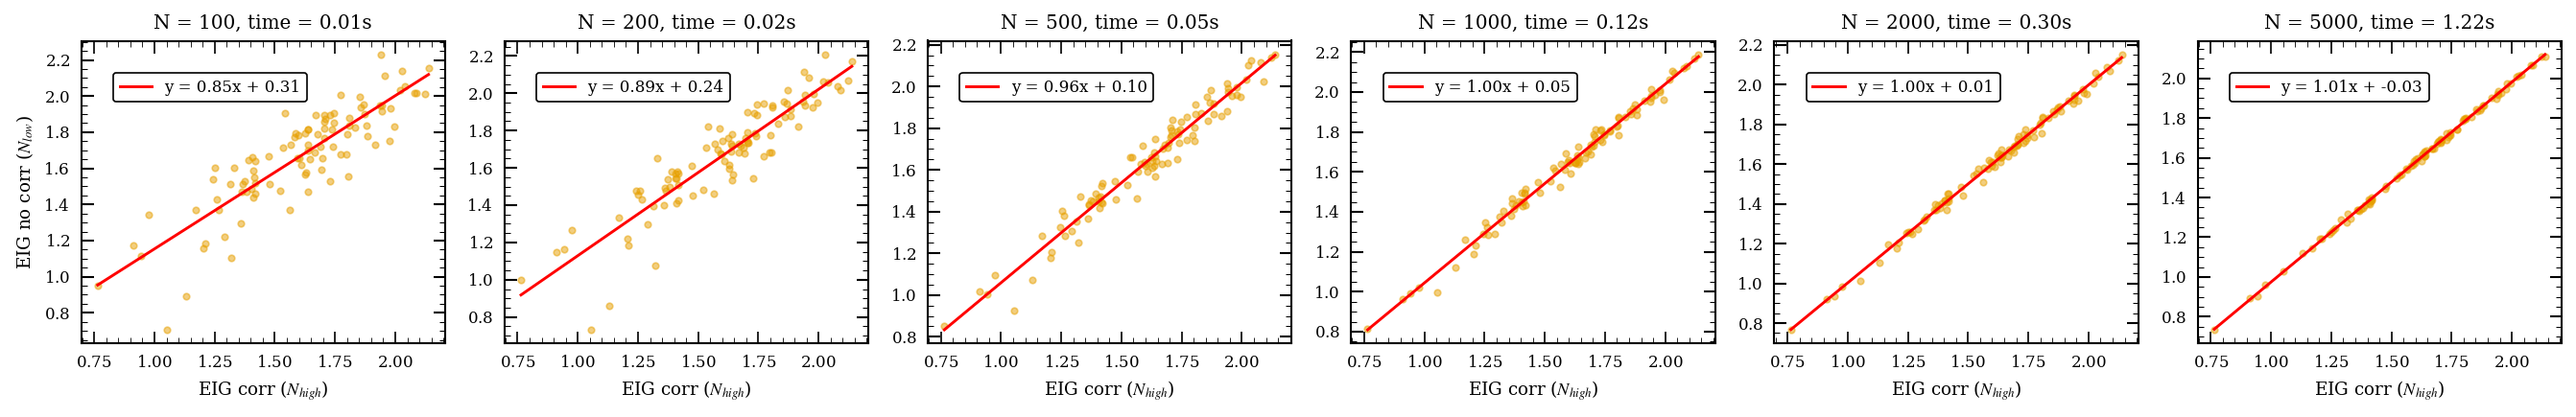

In [15]:
# For each N except the highest, plot EIGs and fit line
# N_plot = [500, 1000, 2000, 5000]
N_plot = [100, 200, 500, 1000, 2000, 5000]

fig, axs = plt.subplots(
    1, len(N_plot),
    figsize=(3 * (len(N_plot)), 3))

axs = axs.ravel()

for i, N_low in enumerate(N_plot):
    # Get EIGs for N_low and N_high from correlated and uncorrelated data
    N_high = N_scenarios[-1]
    
    # Get EIG data from correlated and uncorrelated calculations
    eig_no_corr = EIG_dict_no_corr[N_low]
    eig_corr = EIG_dict_no_corr[N_high]
    
    # Fit line
    slope, intercept = np.polyfit(eig_corr, eig_no_corr, 1)
    line_x = np.array([eig_corr.min(), eig_corr.max()])
    line_y = slope * line_x + intercept
    
    # Plot
    axs[i].scatter(eig_corr, eig_no_corr, alpha=0.5, s=10)
    axs[i].plot(line_x, line_y, 'r-', label=f'y = {slope:.2f}x + {intercept:.2f}')
    axs[i].set_xlabel(f'EIG corr ($N_{{high}}$)')
    if i == 0:
        axs[i].set_ylabel(f'EIG no corr ($N_{{low}}$)')
    axs[i].set_title(f'N = {N_low}, time = {walltime_dict_no_corr[N_low]:.2f}s')
    
    axs[i].legend()
    
plt.tight_layout()
    
plt.show()

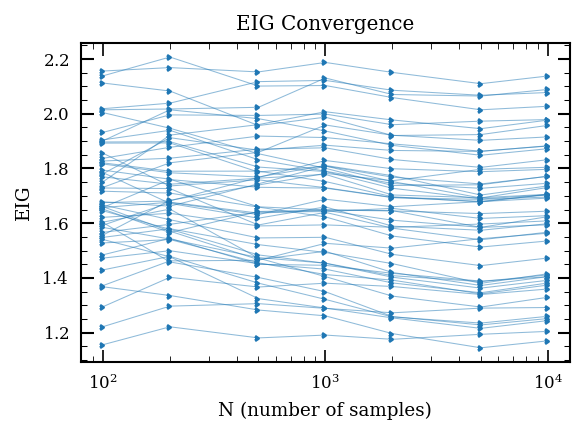

In [16]:
N_designs_plot = 50

# Create a figure with a single axis
fig, ax = plt.subplots(figsize=(4, 3))

# Plot individual design trajectories with low opacity
for design_idx in range(len(designs[:N_designs_plot])):
    eig_values = [EIG_dict_no_corr[(N)][design_idx].item() for N in N_scenarios]
    ax.plot(N_scenarios, eig_values, color='tab:blue', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.scatter(N_scenarios, eig_values, color='tab:blue', s=5, marker=5)

# Set log scale for x-axis
ax.set_xscale('log')

# Add labels and title
ax.set_xlabel('N (number of samples)')
ax.set_ylabel('EIG')
ax.set_title('EIG Convergence')


plt.tight_layout()
plt.show()

In [17]:
# from helpers.geographic_setup import (
#     design_space_full, design_space_shoulder,
#     events_shoulder, events_full, topo_data
# )
# from helpers.helper_functions import (
#     concave_hull2D_prior_dist_constructor
# )


# design_space_dist = concave_hull2D_prior_dist_constructor(
#         design_space_full[..., :3], topo_data,
#         base_dist='sobol',
#         buffer=20, depth=0, ratio=0.05,
#     )

# torch.manual_seed(0)
# random_design_list = torch.stack([
#     design_space_dist.sample(5) for _ in range(5)
# ]).float()  
    
# # for each design in the list, find closest design in design_space
# indices = torch.cdist(random_design_list, design_space_full[..., :3]).argmin(dim=-1)
# random_design_list = design_space_full[indices]

In [18]:
# plt.figure(figsize=(10, 8))

# # Create scatter plot using x, y coordinates (first two columns)
# for designs in random_design_list:
#     plt.scatter(designs[..., 0], designs[..., 1], s=40)

# # Add labels and title
# plt.xlabel('Easting (m)')
# plt.ylabel('Northing (m)')
# plt.title('Random Design Locations')

# # Add grid for better readability
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()